# Загрузка библиотек

In [151]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [152]:
import pandas as pd
import sys
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

In [153]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *
from models.class_models import *
from models.hyperparams_tuning import *
from models.blending import *

In [154]:
import wandb
wandb.login(key='8b1f2ae49570ea59dc8612ff434ca497d463d221')

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [ ]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
stranger_things = ['voltage', 'long_impulse_duration', 'long_impulse_dur_binary']
df.drop(columns=stranger_things, inplace=True)
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Моделирование

## Baseline 1. Featurewiz + XGBoost

### Splashing

In [ ]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost, splashing, no strange columns'
)

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.828125,0.815385,0.821705,65.000000
1,0.796610,0.810345,0.803419,58.000000
accuracy,0.813008,0.813008,0.813008,0.813008
macro avg,0.812368,0.812865,0.812562,123.000000
weighted avg,0.813264,0.813008,0.813082,123.000000


#### Cross-Validation

In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	80.65% (std: 2.91%)
F1 Test:	76.55% (std: 6.04%)


#### SHAP interpretation

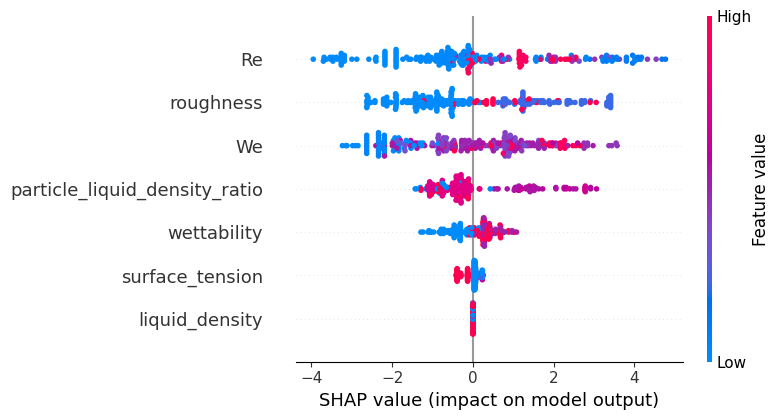

In [ ]:
get_shap_interpretation(model, X_train)

#### Net impact

In [ ]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost, net_impact, no strange columns'
)

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.882353,0.914634,0.898204,82.000000
1,0.815789,0.756098,0.784810,41.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.849071,0.835366,0.841507,123.000000
weighted avg,0.860165,0.861789,0.860406,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	70.80% (std: 4.32%)
F1 Test:	83.84% (std: 6.43%)


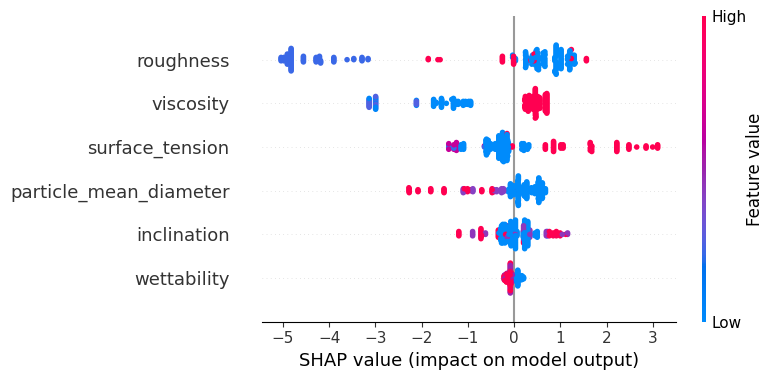

In [ ]:
get_shap_interpretation(model, X_train)

## Baseline 2. Featurewiz + XGBoost + SMOTENC

### Splashing

In [ ]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost + SMOTENC, splashing, no strange columns'
)

In [ ]:
smote_nc = SMOTENC(categorical_features=[6], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.828125,0.815385,0.821705,65.000000
1,0.796610,0.810345,0.803419,58.000000
accuracy,0.813008,0.813008,0.813008,0.813008
macro avg,0.812368,0.812865,0.812562,123.000000
weighted avg,0.813264,0.813008,0.813082,123.000000


#### Cross-Validation

In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.07% (std: 4.34%)
F1 Test:	76.55% (std: 6.04%)


#### SHAP interpretation

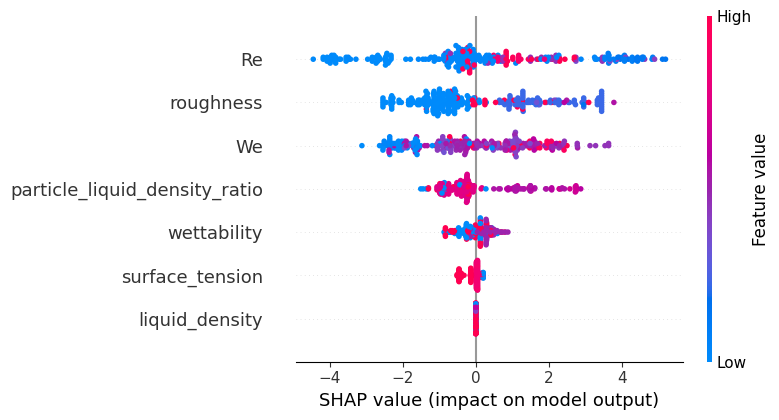

In [ ]:
get_shap_interpretation(model, X_train)

### net_impact

In [ ]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
smote_nc = SMOTENC(categorical_features=[5], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost + SMOTENC, net_impact, no strange columns'
)

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.933333,0.853659,0.891720,82.000000
1,0.750000,0.878049,0.808989,41.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.841667,0.865854,0.850354,123.000000
weighted avg,0.872222,0.861789,0.864143,123.000000


#### Cross-Validation

In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	83.28% (std: 5.76%)
F1 Test:	83.84% (std: 6.43%)


#### SHAP interpretation

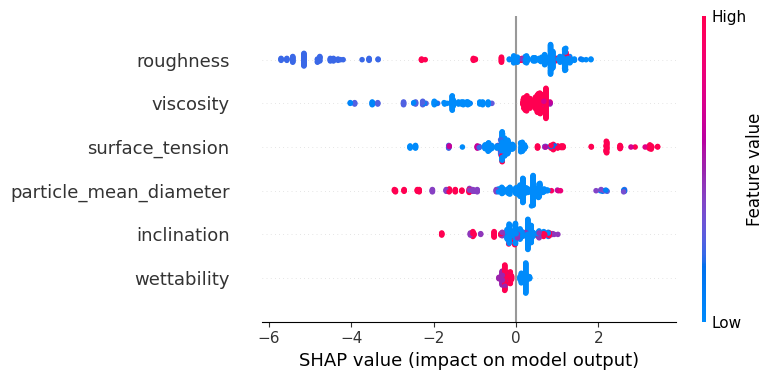

In [ ]:
get_shap_interpretation(model, X_train)

# Модель на признаках из сообщения от 11 апреля в 10:09 в tg


Со Splashing и net_impact посложнее.

- По Re и We: возможны два датасета, в одном Re и We (два признака), в другом We_Re (один признак, либо ещё оставить We исходя из отсутствия мультиколлинеарности с We_Re)
- Второй важный признак тоже wettability_lyophobic
- Далее:
  - volume_fraction_binary, 
  - particle_liquid_density_ratio, 
  - particle_droplet_diameter_ratio (или particle_diameter_cat_large & _small),  
  - и возможно roughness_binary,

In [ ]:
features = ['We', 'We_Re', 
'wettability_lyophobic', 'volume_fraction_binary', 
'particle_liquid_density_ratio', 'particle_droplet_diameter_ratio', 
'roughness_binary']

## Spalashing

In [ ]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg, splashing, no strange columns'
)

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.833333,0.846154,0.839695,65.000000
1,0.824561,0.810345,0.817391,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.828947,0.828249,0.828543,123.000000
weighted avg,0.829197,0.829268,0.829178,123.000000


,precision,recall,f1-score,support
0,0.833333,0.846154,0.839695,65.000000
1,0.824561,0.810345,0.817391,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.828947,0.828249,0.828543,123.000000
weighted avg,0.829197,0.829268,0.829178,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	78.86% (std: 4.02%)
F1 Test:	70.23% (std: 5.12%)


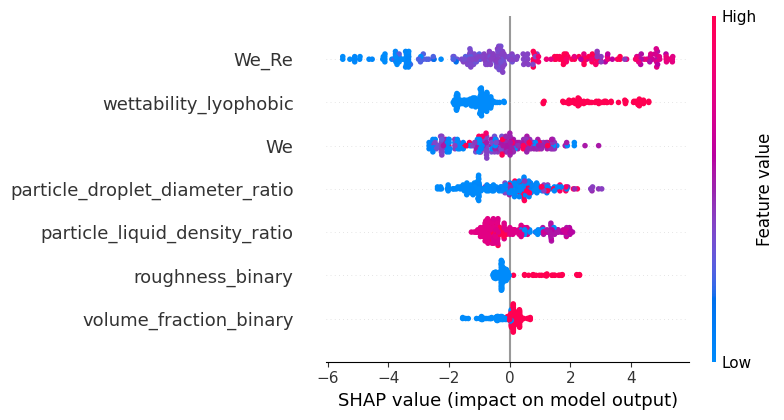

In [ ]:
get_shap_interpretation(model, X_train)

## Net-impact

In [ ]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg, net_impact, no strange columns'
)

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.879518,0.890244,0.884848,82.000000
1,0.775000,0.756098,0.765432,41.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.827259,0.823171,0.825140,123.000000
weighted avg,0.844679,0.845528,0.845043,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	63.79% (std: 3.56%)
F1 Test:	62.84% (std: 14.14%)


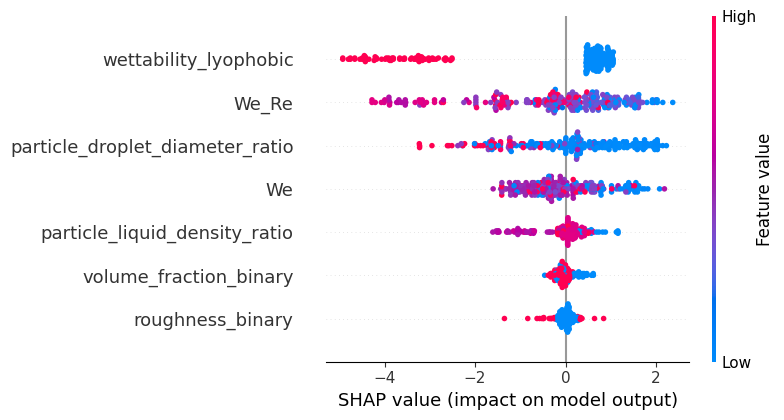

In [ ]:
get_shap_interpretation(model, X_train)

# CatBoost на тех же признаках

## Splashing

In [ ]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg + CatBoost, splashing, no strange columns'
)

In [ ]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.859375,0.846154,0.852713,65.000000
1,0.830508,0.844828,0.837607,58.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.844942,0.845491,0.845160,123.000000
weighted avg,0.845763,0.845528,0.845590,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	81.30% (std: 5.14%)
F1 Test:	78.70% (std: 5.90%)


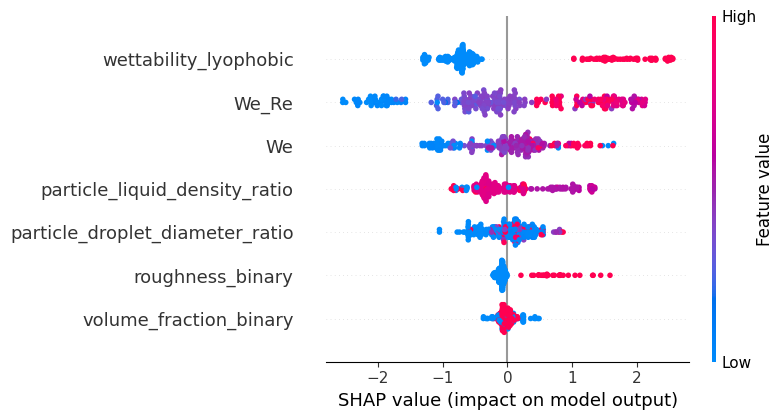

In [ ]:
get_shap_interpretation(model, X_train)

## Net-impact

In [ ]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg + CatBoost, net_impact, no strange columns'
)

In [ ]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.863636,0.926829,0.894118,82.000000
1,0.828571,0.707317,0.763158,41.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.846104,0.817073,0.828638,123.000000
weighted avg,0.851948,0.853659,0.850464,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	73.54% (std: 4.36%)
F1 Test:	67.93% (std: 13.25%)


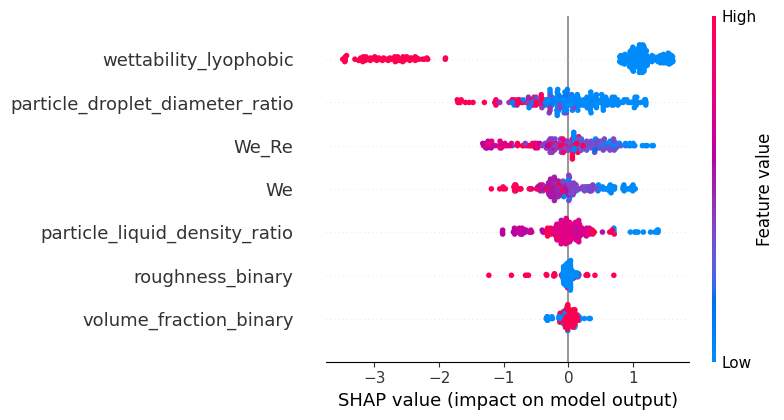

In [ ]:
get_shap_interpretation(model, X_train)

## Baseline 2.1 Featurewiz + CatBoost + SMOTENC

### Splashing

In [ ]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
smote_nc = SMOTENC(categorical_features=[6], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC, splashing, no strange columns'
)

In [ ]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.828571,0.892308,0.859259,65.000000
1,0.867925,0.793103,0.828829,58.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.848248,0.842706,0.844044,123.000000
weighted avg,0.847128,0.845528,0.844910,123.000000


#### Cross-Validation

In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.55% (std: 1.94%)
F1 Test:	78.93% (std: 6.50%)


#### SHAP interpretation

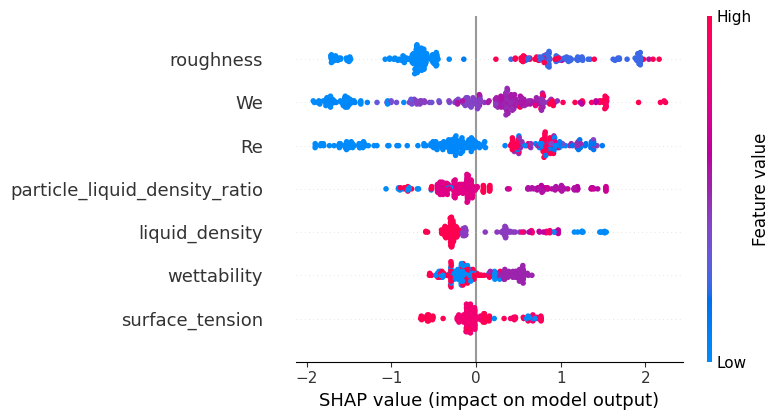

In [ ]:
get_shap_interpretation(model, X_train)

### net_impact

In [ ]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
smote_nc = SMOTENC(categorical_features=[5], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC, net_impact, no strange columns'
)

In [ ]:
model = XGBClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.933333,0.853659,0.891720,82.000000
1,0.750000,0.878049,0.808989,41.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.841667,0.865854,0.850354,123.000000
weighted avg,0.872222,0.861789,0.864143,123.000000


#### Cross-Validation

In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	83.28% (std: 5.76%)
F1 Test:	83.84% (std: 6.43%)


#### SHAP interpretation

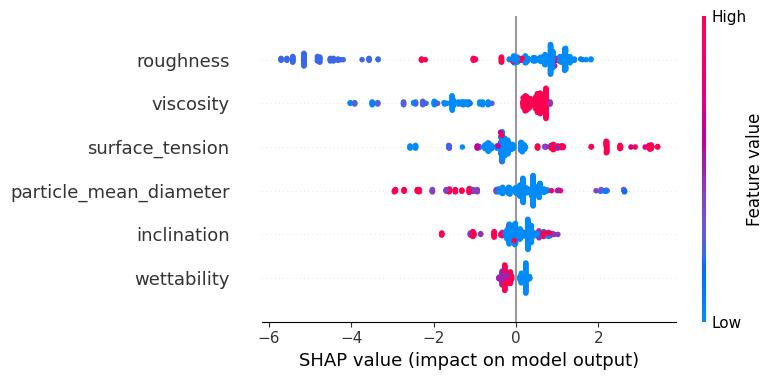

In [ ]:
get_shap_interpretation(model, X_train)

Лучшая модель для splashing: featurewiz + CatBoost + SMOTENC

Лучшая модель для net_impact: featurewiz + CatBoost + SMOTENC

# Подбор гиперпараметров

## splashing: featurewiz + CatBoost + SMOTENC

In [ ]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
smote_nc = SMOTENC(categorical_features=[6], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, splashing, no strange columns'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=70, timeout=None)

In [ ]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/splashing')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.854839,0.815385,0.834646,65.000000
1,0.803279,0.844828,0.823529,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.829059,0.830106,0.829088,123.000000
weighted avg,0.830526,0.829268,0.829404,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	81.17% (std: 6.07%)
F1 Test:	79.63% (std: 5.75%)


## net_impact: featurewiz + CatBoost + SMOTENC

In [ ]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
smote_nc = SMOTENC(categorical_features=[5], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, net_impact, no strange columns'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=70, timeout=None)

In [ ]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/net_impact')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.948052,0.890244,0.918239,82.000000
1,0.804348,0.902439,0.850575,41.000000
accuracy,0.894309,0.894309,0.894309,0.894309
macro avg,0.876200,0.896341,0.884407,123.000000
weighted avg,0.900151,0.894309,0.895684,123.000000


In [ ]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.46% (std: 4.89%)
F1 Test:	81.60% (std: 10.33%)


# featurewiz + Blending + XGBoost + LightGBM + CatBoost

## Splashing

In [ ]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.3)

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
model = BlendingModels()
model.fit(X_train, X_val, y_train, y_val)
y_preds = model.predict(X_test)

In [ ]:
smote_nc = SMOTENC(categorical_features=[6], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + Blending + XGBoost + LightGBM + CatBoost, splashing, no strange columns'
)

In [ ]:
# y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba=None, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.594595,1.000000,0.745763,22.000000
1,0.000000,0.000000,0.000000,15.000000
accuracy,0.594595,0.594595,0.594595,0.594595
macro avg,0.297297,0.500000,0.372881,37.000000
weighted avg,0.353543,0.594595,0.443426,37.000000


## net_impact

In [ ]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.3)

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
model = BlendingModels()
model.fit(X_train, X_val, y_train, y_val)
y_preds = model.predict(X_test)

In [ ]:
smote_nc = SMOTENC(categorical_features=[5], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + Blending + XGBoost + LightGBM + CatBoost, net_impact, no strange columns'
)

In [ ]:
# y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba=None, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.350000,0.304348,0.325581,23.000000
1,0.058824,0.071429,0.064516,14.000000
accuracy,0.216216,0.216216,0.216216,0.216216
macro avg,0.204412,0.187888,0.195049,37.000000
weighted avg,0.239825,0.216216,0.226800,37.000000
